# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv('../content/credit_risk_dataset.csv')

print(f"Розмір датасету: {df.shape}")
print(f"Кількість клієнтів: {df.shape[0]:,}")
print(f"Кількість ознак: {df.shape[1]}")

Розмір датасету: (32581, 12)
Кількість клієнтів: 32,581
Кількість ознак: 12


In [7]:
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [9]:
lstatus_dist = df['loan_status'].value_counts()
lstatus_percent = df['loan_status'].value_counts(normalize=True) * 100

lstatus_percent

,proportion
loan_status,
0,78.183604
1,21.816396


Наявна задача незбалансованої класифікації, оскільки приблизно 78% клієнтів - відносяться до класу "Сплачено", і 22% - до класу "Дефолт".


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [10]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_percent

,0
person_age,0.000000
person_income,0.000000
person_home_ownership,0.000000
person_emp_length,2.747000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_int_rate,9.563856
loan_status,0.000000
loan_percent_income,0.000000


In [11]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

/tmp/ipykernel_27049/3887903077.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
/tmp/ipykernel_27049/3887903077.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

In [12]:
missing = df.isnull().sum()
missing[missing > 0]

,0


Розподіл числових змінних:

In [13]:
df.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Згідно із описом розподілу, як мінімум є неадекватні дані в стовпці person_age (144), та person_emp_length (123). Середній вік позичальника - 28 років, стаж роботи майже 5 років.

**Обробка викидів в колонці person_age:**

In [14]:
Q1 = df['person_age'].quantile(0.25)
Q3 = df['person_age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['person_age'] < lower) |
    (df['person_age'] > upper)
]

print(f"Кількість викидів: {len(outliers)}")

Кількість викидів: 1494


In [15]:
df_clean = df[
    (df['person_age'] >= lower) &
    (df['person_age'] <= upper)
]

**Обробка викидів в колонці person_emp_length:**

In [16]:
Q1 = df_clean['person_emp_length'].quantile(0.25)
Q3 = df_clean['person_emp_length'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean['person_emp_length'] < lower) |
    (df_clean['person_emp_length'] > upper)
]

print(f"Кількість викидів: {len(outliers)}")

Кількість викидів: 695


In [17]:
df_clean2 = df_clean[
    (df_clean['person_emp_length'] >= lower) &
    (df_clean['person_emp_length'] <= upper)
]

In [18]:
fig = px.histogram(
    df_clean2,
    x='person_age',
    nbins=100,
    title='Розподіл віку',
    labels={'person_age': 'Вік', 'count': 'Кількість осіб'}
)
fig.update_layout(
    showlegend=False,
    height=300, width=500
)
fig.show()

**Аналіз категоріальних змінних відносно цільової:**

In [19]:
# Статус кредиту vs Мета кредиту
intent_status = df_clean2.groupby(['loan_intent', 'loan_status']).size().unstack()
intent_status_pct = intent_status.div(intent_status.sum(axis=1), axis=0) * 100

fig = px.bar(
    intent_status_pct.T,
    title='Статус кредиту за метою кредитування',
    labels={'value': 'Відсоток (%)', 'index': 'Статус'},
    color_discrete_map={'0':'#2ecc71', '1':'#e74c3c'},
    barmode='group'
)
fig.update_layout(
    height=400, width=1000
)
fig.show()

Отже, всі категорії кредиту представлені в дефолтних кредитах, найбільшу частку займають кредити рефінансування (28%), найменше - кредити на освітні цілі та венчурні кредити (17% та 15% відповідно).

In [20]:
# Статус кредиту vs Попередня кредитна історія (наявність дефолту)
default_status = df_clean2.groupby(['cb_person_default_on_file', 'loan_status']).size().unstack()
default_status_pct = default_status.div(default_status.sum(axis=1), axis=0) * 100

fig = px.bar(
    default_status_pct.T,
    title='Статус кредиту за попереднім дефолтом позичальника',
    labels={'value': 'Відсоток (%)', 'index': 'Статус'},
    color_discrete_map={'0':'#2ecc71', '1':'#e74c3c'},
    barmode='group'
)
fig.update_layout(
    height=300, width=650
)
fig.show()

Отже, за наявності минулого дефолту, майже 38% кредитів знову потрапляють в дефолт, в іншому випадку - лише 18,5%.

In [21]:
# Статус кредиту vs Кредитний рейтинг позичальника
grade_status = df_clean2.groupby(['loan_grade', 'loan_status']).size().unstack()
grade_status_pct = grade_status.div(grade_status.sum(axis=1), axis=0) * 100

fig = px.bar(
    grade_status_pct.T,
    title='Статус кредиту за визначеним кредитним рейтингом',
    labels={'value': 'Відсоток (%)', 'index': 'Рейтинг'},
    color_discrete_map={'0':'#2ecc71', '1':'#e74c3c'},
    barmode='group'
)
fig.update_layout(
    height=350, width=800
)
fig.show()

Як і очукувалося, між показниками дефолту та визначеного кредитного рейтингу простежується обернений звʼязок (при найкращому рейтингу А - найменший відсоток дефолту 10%, при найгіршому ретингу G - найвищий відсоток дефолту - 98%). Відсоток дефолту суттєво збільшується  починаючи з ретингу D.

**Аналіз звʼязку ознак з цільовою змінною (статусом кредиту):**

In [22]:
# Статус кредиту vs Вік позичальника
fig = px.box(
    df_clean2,
    x='loan_status',
    y='person_age',
    title='Кредитний статус vs Вік',
    labels={'person_age': 'Вік', 'loan_status': 'Статус'},
    color='loan_status',
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'}
)
fig.update_layout(
    height=400, width=800
)
fig.show()

Медіанний вік позичальників у дефолтних кредитах трохи менший, за вік позичальників, які погасили кредити. Схоже, що змінна віку не є визначальною для дефолтності.

In [23]:
# Статус кредиту vs Дохід позичальника
fig = px.box(
    df_clean2,
    x='loan_status',
    y='person_income',
    title='Кредитний статус vs Дохід',
    labels={'person_income': 'Дохід', 'loan_status': 'Статус'},
    color='loan_status',
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'}
)
fig.update_layout(
    height=600, width=1000
)
fig.show()

Показник доходу може здійснювати вплив на можливу дефолтність кредиту, середній показник для погашеного кредиту 60 тис. од., для дефолтного - 40 тис.од. Однак в обох випадках досить багато аутлаєрів.

In [24]:
# Статус кредиту vs Розмір кредиту
fig = px.box(
    df_clean2,
    x='loan_status',
    y='loan_amnt',
    title='Кредитний статус vs Розмір кредиту',
    labels={'loan_amnt': 'Розмір кредиту', 'loan_status': 'Статус'},
    color='loan_status',
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'}
)
fig.update_layout(
    height=600, width=1000
)
fig.show()

Спостерігаємо відмінності між середніми обсягами погашеного кредиту та дефолтного, однак абсолютна різниця в обсягах на нашу думку не є визначальною.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [26]:
metrics_df = df_clean2.select_dtypes("number").dropna()

correlation_matrix = metrics_df.corr()

fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між числовими метриками',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=550)
fig.show()

Найбільший позитивний лінійний звʼязок спостерігаємо між показниками обсягу кредиту та коеф. Кредит/Дохід. Щодо цільового показника Статус кредиту, то найбільший звʼязок із дефолтом встановлено з % ставкою за кредитом (0,32) та коеф. Кредит/Дохід (0,38). Тобто, зі збільшенням ставки за кредитом збільшується ризик дефолту, а також при зростанні співвідношення Кредит/Дохід - ризик дефолту збільшується. Найбільше впливає на "погашення" кредиту Дохід клієнта (-0,19).

In [27]:
all_cat_cols = df_clean2.select_dtypes('object').columns.tolist()

In [28]:
all_cat_cols

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

**Кодування категоріальних змінних та вибір фінальних ознак**

In [36]:
selected_cat_cols = ['loan_grade', 'cb_person_default_on_file']

df_encoded = pd.get_dummies(df_clean2, columns=selected_cat_cols, drop_first=False)

df_encoded_mod = df_encoded[['loan_status', 'loan_amnt',	'loan_int_rate', 'loan_percent_income',
                             'loan_grade_A',	'loan_grade_B',	'loan_grade_C',	'loan_grade_D',
                             'loan_grade_E',	'loan_grade_F',	'loan_grade_G', 'cb_person_default_on_file_Y']]

Обрані ознаки з найбільшою кореляцією до цільової змінної, а також ознаки за результатами попередніх візуалізацій.

In [37]:
df_encoded_mod.head(3)

,loan_status,loan_amnt,loan_int_rate,loan_percent_income,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,0,1000,11.14,0.10,False,True,False,False,False,False,False,False
2,1,5500,12.87,0.57,False,False,True,False,False,False,False,False
3,1,35000,15.23,0.53,False,False,True,False,False,False,False,False



---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [38]:
X = df_encoded_mod.drop(columns=['loan_status'])
y = df_encoded_mod['loan_status']

print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 11
Розмір вибірки: 30392


**Розподіл на вибірки**

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=44,
    stratify=y
)

print(f"Train: {X_train.shape[0]} позичальників")
print(f"Test: {X_test.shape[0]} позичальників")
print(f"Дефолт кредитів в train: {y_train.mean():.1%}")
print(f"Дефолт кредитів в test: {y_test.mean():.1%}")

Train: 24313 позичальників
Test: 6079 позичальників
Дефолт кредитів в train: 22.0%
Дефолт кредитів в test: 22.0%


**Масштабування даних**

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Навчання моделі**

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=44, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


**Прогнози**

In [44]:
# Прогноз класів
y_pred = model.predict(X_test_scaled)

# Прогноз ймовірності
y_pred_proba = model.predict_proba(X_test_scaled)

In [46]:
sample_predictions = pd.DataFrame({
    'Реальний дефолт': y_test.values[:10],
    'Прогноз': y_pred[:10],
    'Ймовірність погаситися': y_pred_proba[:10, 0].round(3),
    'Ймовірність дефолту': y_pred_proba[:10, 1].round(3)
})
print(sample_predictions)

   Реальний дефолт  Прогноз  Ймовірність погаситися  Ймовірність дефолту
0                0        0                   0.814                0.186
1                0        0                   0.934                0.066
2                0        0                   0.919                0.081
3                1        0                   0.953                0.047
4                0        1                   0.410                0.590
5                0        1                   0.196                0.804
6                0        0                   0.905                0.095
7                0        0                   0.958                0.042
8                1        0                   0.521                0.479
9                0        0                   0.824                0.176


Бачимо, що модель не дуже точна. 4 помилки з 10 записів, 2 з яких дуже неточні.


---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


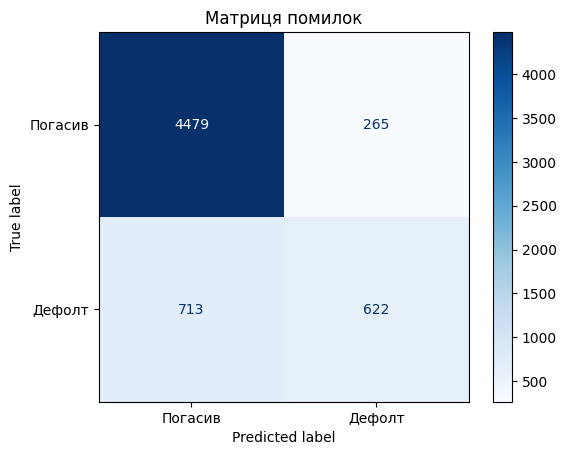

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Погасив', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

Бачимо, що прогноз погашень, які виявилися дефолтом, досить великий (і більший за правильний прогноз дефолтів).

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.839
Precision (Влучність):  0.701
Recall (Повнота):       0.466
F1-score:               0.560


Показник "Влучність" досить високий, на відміну від показника "Повнота", з ним проблеми.

In [49]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

Показник AUC=0,845 - це показник хорошої моделі. ROC-крива, однак, далека від ідеального стану.

**Важливість ознак:**

In [50]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
2,loan_percent_income,1.341421,1.341421
0,loan_amnt,-0.686573,0.686573
6,loan_grade_D,0.570956,0.570956
7,loan_grade_E,0.359424,0.359424
3,loan_grade_A,-0.335830,0.335830
9,loan_grade_G,0.250550,0.250550
8,loan_grade_F,0.197519,0.197519
4,loan_grade_B,-0.188815,0.188815
1,loan_int_rate,0.164681,0.164681
5,loan_grade_C,-0.057467,0.057467


Найбільший "позитивний" вплив на дефолтність справляє коеф. Кредит/Дохід, як ми і бачили в кореляційній матриці. Величина кредиту навпаки, впливає негативно. Кредитні рейтинги D та E серед інших мають найбільший показник впливу на дефолт. А ось показник наявність попередньої дефолтної історії практично не має впливу на цільовий показник, хоча ми цього очікували. Хоча загальні показники моделі досить непогані, однак, здається окремі впливові фактори не були включені до аналізу (наприклад, тип житла і стаж роботи).


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [51]:
thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)
fig.show()

Судячи з візуалізації, оптимальним порогом було б 0,35 (замість 0,5). Можливо цього буде достатньо для підвищення значення показника Recall, f1 також має зрости за такого рівня.

**Розрахунок на декілька порогів:**

In [65]:
thresholds_ = [0.2, 0.3, 0.35, 0.4, 0.5]

metrics_by_threshold = []

for threshold in thresholds_:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold).round(3)

print(metrics_df)

   threshold  precision  recall     f1
0       0.20      0.519   0.762  0.617
1       0.30      0.604   0.692  0.645
2       0.35      0.635   0.640  0.637
3       0.40      0.651   0.579  0.613
4       0.50      0.701   0.466  0.560


Найкрашим виглядає варіант з порогом 0.3 - там максимальний f1.

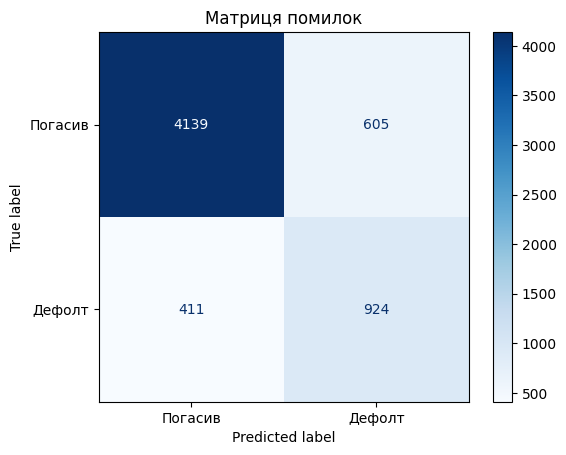

In [66]:
y_pred_opt = y_pred_proba[:,1]>=0.3
cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Погасив', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

Теоретично, банк більше зацікавлений в коректному прогнозі дефолту, бо поточні кредити і так будуть моніторитися періодично, тому зростання FN не повинно бути більшою проблемою, в порівнянні із вигодами від зменшення FP.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [68]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# альтернативні моделі
models = {
    'Logistic Regression': LogisticRegression(random_state=44, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=44, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=44, n_estimators=100)
}

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    if name == 'Logistic Regression':
        y_pred = (y_pred_proba >= 0.3).astype(int)
    else:
        y_pred = model.predict(X_test_scaled)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                 Model  Accuracy  Precision  Recall     F1    AUC
0  Logistic Regression     0.833      0.604   0.692  0.645  0.845
1        Decision Tree     0.841      0.641   0.623  0.632  0.836
2        Random Forest     0.852      0.681   0.609  0.643  0.857


Найкращий результат дає Random Forest, тут більший AUC та f1 на рівні із логістичною регресією. Головне питання, якому показнику приділити більшу увагу: Precision чи Recall? Для прогнозування прострочки за кредитами, накраще звертати увагу на Recall, тому обираємо логістичну регресію з порогом 0.3.